Generating analytical flags...
Applying analytical categories...
Data saved to data\cleaned\alameda_citywide_master.parquet
Rendering maps...


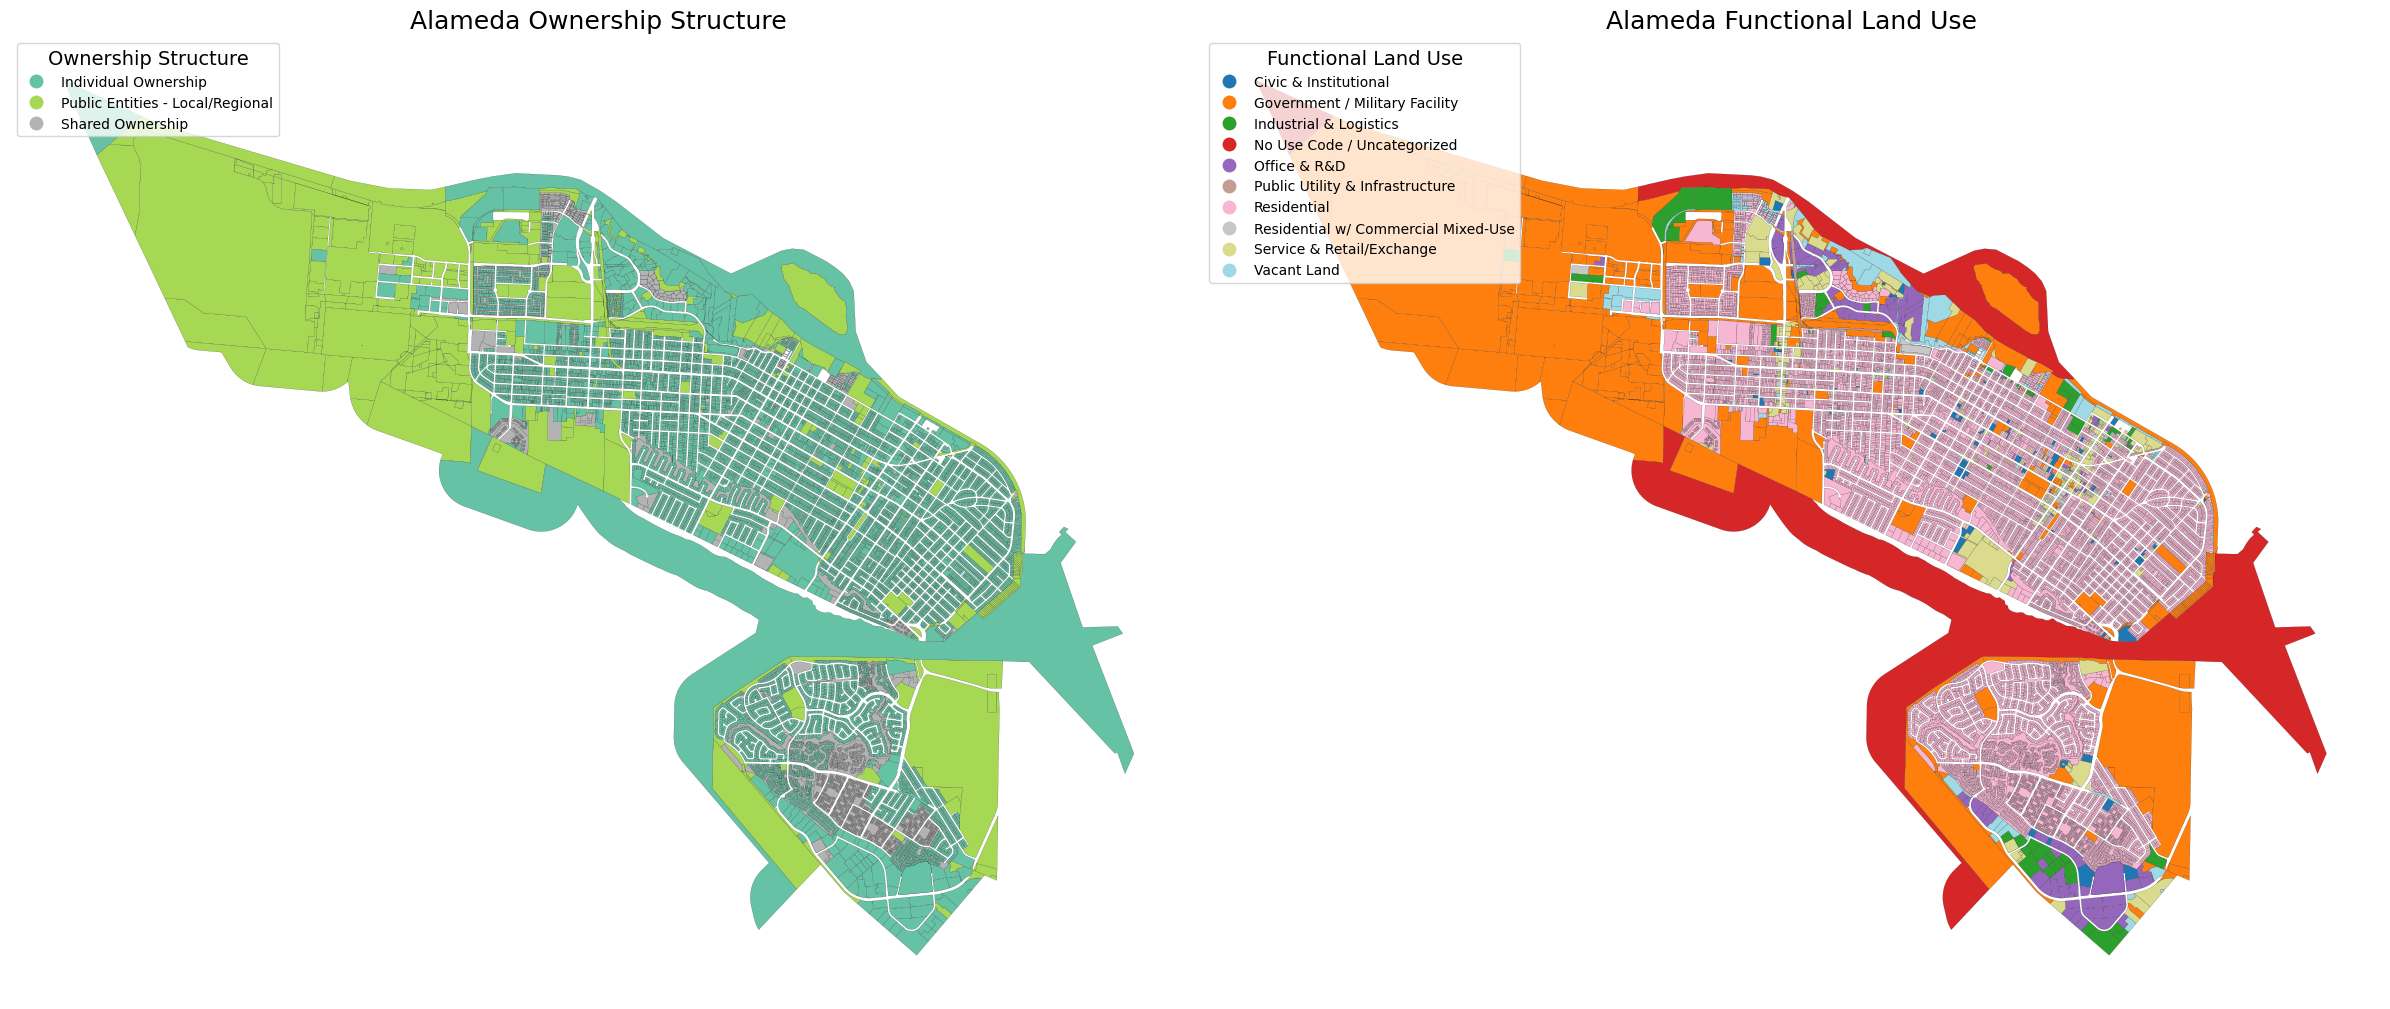


--- Ownership Structure ---
ownership_structure
Individual Ownership                16399
Shared Ownership                     5126
Public Entities - Local/Regional      575
Name: count, dtype: int64

--- Land Use Category ---
land_use_category
Residential                            20262
Government / Military Facility           542
Vacant Land                              414
Service & Retail/Exchange                380
Residential w/ Commercial Mixed-Use      169
Office & R&D                             141
Civic & Institutional                     91
Industrial & Logistics                    76
Public Utility & Infrastructure           23
No Use Code / Uncategorized                2
Name: count, dtype: int64


In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re
from pathlib import Path

# 1. Load the raw geodatabase
gdb_path = r"data\raw\alameda_parcel_ownership_20260915.gdb"
gdf = gpd.read_file(gdb_path, layer="PARCEL_With_Ownership")

# 2. Jurisdictional Filter (Alameda City & Tideland Proxies)
# Keep parcels in Alameda City (TRA starts with 21) OR placeholder APNs (999-9999)
tra_col = next((col for col in gdf.columns if 'tra' in col.lower() or 'tax' in col.lower()), None)
if tra_col:
    is_alameda = gdf[tra_col].astype(str).str.startswith('21')
    is_placeholder_apn = gdf['apn'].astype(str).str.contains('999-9999', na=False)
    gdf = gdf[is_alameda | is_placeholder_apn].copy()

# Dynamically identify columns
owner_col = next((col for col in gdf.columns if 'owner' in col.lower() or 'assessee' in col.lower() or 'name' in col.lower()), None)
usecode_col = next((col for col in gdf.columns if 'use' in col.lower() and 'code' in col.lower()), 'usecode')
mail_city_col = next((col for col in gdf.columns if 'mail' in col.lower() and 'city' in col.lower()), 'mailingaddresscity')
situs_zip_col = next((col for col in gdf.columns if 'situs' in col.lower() and 'zip' in col.lower()), 'situszip')
mail_zip_col = next((col for col in gdf.columns if 'mail' in col.lower() and 'zip' in col.lower()), 'mailingaddresszip')

# 3. Create Analytical Proxy Columns
print("Generating analytical flags...")

# A. Tideland Proxy (For fact-checking: Placeholder APNs or >1M sqft with $0 value)
gdf['area_sqft'] = gdf.geometry.area
gdf['is_tideland_proxy'] = (
    gdf['apn'].astype(str).str.contains('999-9999', na=False) | 
    ((gdf['area_sqft'] > 1000000) & (gdf['totalnetvalue'].fillna(0) == 0))
)

# B. Water Dependent Properties (Tidelands, Salt Ponds 4700, Boat Berths 9901, Floating Homes 750)
gdf['water_dependent'] = (
    gdf['is_tideland_proxy'] | 
    gdf[usecode_col].astype(str).str.strip().isin(['750', '4700', '9901'])
)

# C. Registration Type (Local vs External)
if mail_city_col in gdf.columns:
    gdf['registration_type'] = np.where(
        gdf[mail_city_col].astype(str).str.strip().str.upper().str.contains('ALAMEDA', na=False),
        'Locally Registered',
        'Externally Registered'
    )

# D. Owner-Occupied Proxy (Compare property ZIP to mailing ZIP)
if situs_zip_col in gdf.columns and mail_zip_col in gdf.columns:
    gdf['owner_occupied_proxy'] = gdf[situs_zip_col].astype(str).str.strip() == gdf[mail_zip_col].astype(str).str.strip()

# 4. Categorization Functions
def categorize_ownership(row):
    use_code_str = str(row.get(usecode_col, '')).strip()
    owner = str(row.get(owner_col, '')).upper() if owner_col else ""
    
    try:
        uc = int(float(use_code_str))
    except ValueError:
        uc = -1
        
    # PUBLIC ENTITIES (3 Tiers)
    is_public_code = uc in [300, 400, 500, 6001, 6100]
    fed_kws    = ['UNITED STATES', 'U S A', 'USA ', 'FEDERAL', 'U S DEPT', 'US GOVT', 'US NAVY', 'COAST GUARD']
    state_kws  = ['STATE OF', 'CALIFORNIA', 'CALTRANS', 'CALIF ', 'DEPT OF TRANSPORTATION', 'UNIV OF CAL', 'UC REGENTS']
    local_kws  = ['CITY OF', 'ALAMEDA CITY', 'COUNTY OF', 'ALAMEDA COUNTY', 'HOUSING AUTH', 'EBMUD', 'PARK DIST', 'SCHOOL DIST', 'BART']
    
    if is_public_code or any(kw in owner for kw in fed_kws + state_kws + local_kws):
        if any(kw in owner for kw in fed_kws): return 'Public Entities - Federal'
        if any(kw in owner for kw in state_kws): return 'Public Entities - State'
        return 'Public Entities - Local/Regional' 
        
    # TRUST & CORPORATE ENTITIES
    if re.search(r'\b(TRUST|TR|FAMILY|LIVING)\b', owner): return 'Trust Entities'
    if re.search(r'\b(LLC|INC|CORP|LTD|LP|COMPANY|CO)\b', owner): return 'Corporate Entities'
        
    # SHARED OWNERSHIP (Condos, Co-ops, Townhomes, and HOA Common Areas)
    common_areas = [1190, 1590, 1690, 1890, 3990, 4191, 7090, 7390, 7391, 7392, 7395, 7790]
    if (1500 <= uc < 1700) or (7300 <= uc < 7400) or uc in [3900, 4101, 7400, 7430] or uc in common_areas:
        return 'Shared Ownership'
        
    return 'Individual Ownership'

def categorize_land_use(row):
    use_code_str = str(row.get(usecode_col, '')).strip()
    
    try:
        uc = int(float(use_code_str))
    except ValueError:
        return 'No Use Code / Uncategorized'
        
    # PUBLIC UTILITY
    if uc in [400, 500]: return 'Public Utility & Infrastructure'
    
    # GOVERNMENT / MILITARY FACILITY
    if uc in [300, 6001, 6100]: return 'Government / Military Facility'
        
    # MARITIME (Strictly Boat Berths based on Use Code)
    if uc == 9901: return 'Maritime & Submerged Lands'
        
    # CIVIC & INSTITUTIONAL
    if (6000 <= uc < 7000) or uc in [8700, 8800, 8801, 8802]: return 'Civic & Institutional'
        
    # RESIDENTIAL W/ COMMERCIAL MIXED-USE
    if uc in [1950, 3200, 3705, 4240, 7301, 7302, 7321, 7322, 7341, 7342, 7391, 7392, 7705, 7706]: 
        return 'Residential w/ Commercial Mixed-Use'
        
    # OFFICE & R&D
    if uc in [4201, 4202, 4205, 9400, 9401, 9405, 9491, 9500]: return 'Office & R&D'
        
    # VACANT LAND
    if uc in [800, 840, 1000, 1040, 3000, 4000, 5000, 5700, 5900, 6000, 7000, 7040, 7090]: 
        return 'Vacant Land'
        
    # INDUSTRIAL & LOGISTICS (4000 series, excluding the R&D/Condo codes caught above)
    if (4000 <= uc < 5000) or uc in [9902]: return 'Industrial & Logistics'
        
    # SERVICE & RETAIL EXCHANGE (3000 series and 8000/9000 series not caught above)
    if (3000 <= uc < 4000) or (8000 <= uc < 10000) or uc == 6850: 
        return 'Service & Retail/Exchange'
        
    # RESIDENTIAL (Includes 8901 SROs and 750 Floating Homes)
    if (1100 <= uc < 3000) or (7000 <= uc < 8000) or uc in [600, 700, 750, 900, 940, 5100, 5200, 8901]: 
        return 'Residential'

    return 'Other / Uncategorized'

print("Applying analytical categories...")
gdf['ownership_structure'] = gdf.apply(categorize_ownership, axis=1)
gdf['land_use_category'] = gdf.apply(categorize_land_use, axis=1)

# 5. Handle Stacked Geometries for Rendering
# Sort to ensure Shared/Condo properties remain visible when dropping duplicates
gdf['is_shared'] = gdf['ownership_structure'] == 'Shared Ownership'
map_gdf = gdf.sort_values('is_shared', ascending=False).drop_duplicates(subset=['geometry'])

# 6. Export Data
output_path = Path("data") / "cleaned" / "alameda_citywide_master.parquet"
output_path.parent.mkdir(parents=True, exist_ok=True)
gdf.to_parquet(output_path, index=False)
print(f"Data saved to {output_path}")

# 7. Build the Dual-Panel Map
print("Rendering maps...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 12))

# Map 1: Ownership Structure
map_gdf.plot(
    ax=ax1, 
    column='ownership_structure', 
    cmap='Set2',
    linewidth=0.1,
    edgecolor='black',
    legend=True,
    legend_kwds={'loc': 'upper left', 'title': 'Ownership Structure', 'title_fontsize': 14}
)
ax1.set_title("Alameda Ownership Structure", fontsize=18)
ax1.set_axis_off()

# Map 2: Land Use
map_gdf.plot(
    ax=ax2, 
    column='land_use_category', 
    cmap='tab20',
    linewidth=0.1,
    edgecolor='black',
    legend=True,
    legend_kwds={'loc': 'upper left', 'title': 'Functional Land Use', 'title_fontsize': 14}
)
ax2.set_title("Alameda Functional Land Use", fontsize=18)
ax2.set_axis_off()

plt.tight_layout()
plt.show()

# Print Summaries
print("\n--- Ownership Structure ---")
print(gdf['ownership_structure'].value_counts())
print("\n--- Land Use Category ---")
print(gdf['land_use_category'].value_counts())